In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [2]:
us = pd.read_csv('../data/processed/user_summary.csv')

before = len(us)
us = us[us['ObservedDays'] >= 14].copy()
print(f'{before}명 → {len(us)}명 (관찰일수 14일 미만 이상치 제외)')

features = ['AvgSteps','AvgActiveMinutes','AvgSedentaryRatio','AvgVeryActiveMinutes','WearRate']
X = us[features].fillna(us[features].median())
Xs = StandardScaler().fit_transform(X)

35명 → 33명 (관찰일수 14일 미만 이상치 제외)


In [3]:
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(Xs)
    scores[k] = silhouette_score(Xs, labels)

best_k = max(scores, key=scores.get)
print('K별 실루엣 스코어:', {k: round(v,3) for k,v in scores.items()})
print('선택된 K:', best_k)

K별 실루엣 스코어: {2: 0.394, 3: 0.336, 4: 0.292, 5: 0.291, 6: 0.289}
선택된 K: 2


In [4]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
us['Cluster'] = km.fit_predict(Xs)

profile = us.groupby('Cluster')[features + ['AvgSteps_Weekend','AvgSteps_Weekday']].mean().round(1)
profile['n'] = us['Cluster'].value_counts().sort_index()
us.to_csv('../data/processed/user_summary_clustered.csv', index=False)
profile

,AvgSteps,AvgActiveMinutes,AvgSedentaryRatio,AvgVeryActiveMinutes,WearRate,AvgSteps_Weekend,AvgSteps_Weekday,n
Cluster,,,,,,,,
0,4589.3,160.4,0.8,6.6,0.8,4589.1,4623.5,11
1,9391.5,276.5,0.6,27.8,1.0,9399.7,9402.5,22


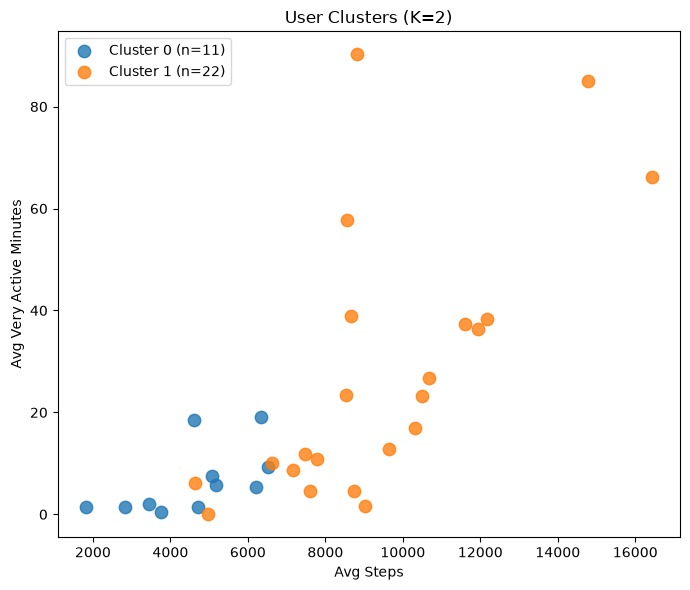

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

cmap = plt.colormaps['tab10']

for c in sorted(us['Cluster'].unique()):
    sub = us[us['Cluster'] == c]
    ax.scatter(
        sub['AvgSteps'],
        sub['AvgVeryActiveMinutes'],
        s=80,
        label=f'Cluster {c} (n={len(sub)})',
        color=cmap(c),
        alpha=0.8,
    )

ax.set_xlabel('Avg Steps')
ax.set_ylabel('Avg Very Active Minutes')
ax.set_title(f'User Clusters (K={best_k})')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/04_clusters.png', dpi=130)
plt.show()